In [96]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction

This notebook estimates the critical temperature of the two-dimensional Ising model by varying $\beta J$ (`BJ`) and measuring the magnetisation and magnetic susceptibility.

The calculation is carried out in two stages:

1. **Coarse sweep**: scan a broad range of `BJ` values to locate the approximate critical region.
2. **Critical-temperature estimation**: scan this region at higher resolution, repeat the calculation several times, and average the results to obtain a more reliable estimate of the critical temperature.

### Definitions

- `step`: one iteration of the Metropolis algorithm. A random spin is selected, a flip is proposed, and the flip is either accepted or rejected.
- `sweep`: $N=L^2$ Metropolis steps, so that on average every spin in the lattice is selected once.
- `block`: a fixed number of sweeps over which the magnetisation and energy are averaged. By default, one block contains 500 sweeps.

A **Monte Carlo sweep** refers to the definition above, while a **`BJ` sweep** refers to running the simulation over a range of `BJ` values.

### Equilibrium Detection

For the coarse sweep, a simple automatic criterion is used to estimate when the system has equilibrated.

After each block, the average absolute reduced magnetisation

$$\langle |\tilde m| \rangle = \left\langle \left|\frac{1}{N}\sum_i \sigma_i\right| \right\rangle$$

and the average energy per spin $E/N$ are calculated. Absolute magnetisation is used because, at zero external field, the $+\tilde m$ and $-\tilde m$ ordered states are equally likely.

The system is considered stable when both quantities change by less than `m_tolerance` and `e_tolerance` for three consecutive blocks. If this condition is not met, the simulation continues until `max_blocks` is reached.

This is only a practical estimate of equilibrium and is not always reliable. For example, the lattice can become temporarily stuck with one large region of $+1$ spins and another of $-1$ spins. The magnetisation and energy may then change very little between blocks even though the system has not reached true equilibrium. In such cases, $|\tilde m|$ can remain close to zero even though the low-temperature equilibrium state should have $|\tilde m|$ close to one.

The criterion also becomes unreliable near the critical temperature, where magnetisation and energy naturally fluctuate strongly. The system may already be behaving statistically steadily while the block averages still vary too much to satisfy the tolerance. Loosening the tolerances would reduce this problem, but would also increase the chance of incorrectly accepting a temporarily stuck configuration as equilibrated.

For these reasons, the automatic equilibrium criterion is used only for the coarse sweep, where the goal is simply to locate the approximate critical region.



### Critical-Temperature Estimation

For the final estimate of the critical temperature, a simpler fixed procedure is used.

At each `BJ`:

1. Start from a randomly generated lattice.
2. Run a fixed number of **burn-in sweeps** and discard these samples.
3. Run a fixed number of additional sweeps for measurement.
4. Calculate the average magnetisation and magnetic susceptibility from the measurement period.

The entire `BJ` sweep is repeated several times from independently generated lattices. The magnetisation and susceptibility at each `BJ` are then averaged across the runs to reduce random Monte Carlo variation.

The critical temperature is estimated from the position of the maximum of the averaged magnetic susceptibility curve.

In [ ]:
L = 80 # number of spins_block in one side of the square lattice (so total there are N = L^2 spins)

# hamiltonian parameters
H = 0.0 # H = mu_s * B / J

# sweep settings. these settings are kept consistent throughout all runs
num_sweeps_per_block = 500
m_tolerance = 0.01 # absolute tolerance since m can be around 0
e_tolerance = 0.01 # relative tolerance
stable_blocks_required = 3

# Function Definitions
### Sweep Function with Equilibrium Detector

In [98]:
def run_critical_temperature_sweep(
    BJ_values,
    max_blocks, 
    L=L, 
    H=H, 
    num_sweeps_per_block=num_sweeps_per_block, 
    stable_blocks_required=stable_blocks_required, 
    m_tolerance=m_tolerance, 
    e_tolerance=e_tolerance
    ):

    N = L**2
    steps = num_sweeps_per_block * N

    magnetisations = []
    susceptibilities = []
    equilibration_blocks = []

    for BJ in BJ_values:
        lattice = ut.generate_lattice(L)
        energy = ut.get_energy(lattice, H)

        block_count = 0
        stable_count = 0
        previous_m = None
        previous_e = None

        while stable_count < stable_blocks_required and block_count < max_blocks:

            lattice, spins, energies, _ = ut.metropolis(lattice, steps, BJ, H, energy)
            m_block = np.mean(np.abs(spins / N))
            e_block = np.mean(energies / N)

            if previous_m is not None: # previous_m and previous_e should both be None or both be not None
                m_change = abs(m_block - previous_m)
                e_change = abs(e_block - previous_e) / max(abs(previous_e), 1e-8) # denominator is floored at 1e-8 to prevent dividing by zero

                if m_change <= m_tolerance and e_change <= e_tolerance:
                    stable_count += 1
                else:
                    stable_count = 0

            previous_m = m_block
            previous_e = e_block
            energy = energies[-1] # latest lattice is returned by ut.metropolis() but not energy. must update manually

            block_count += 1

        # separate equilibrium measurement run
        _, spins, _, _ = ut.metropolis(lattice, 10 * steps, BJ, H, energy)
        m = spins / N
        mean_abs_m = np.mean(np.abs(m))
        chi = BJ * N * (np.mean(m**2) - np.mean(np.abs(m))**2)

        magnetisations.append(mean_abs_m)
        susceptibilities.append(chi)
        equilibration_blocks.append(block_count)

        if stable_count >= stable_blocks_required:
            print(
                f"BJ={BJ:.2f} equilibrated after "
                f"{block_count} blocks "
                f"(|m|={m_block:.3f}, E/N={e_block:.3f})"
            )
        else:
            print(
                f"BJ={BJ:.2f} reached "
                f"{block_count} blocks "
                f"(|m|={m_block:.3f}, E/N={e_block:.3f})"
            )

    return magnetisations, susceptibilities, equilibration_blocks


### Plotting Functions

In [110]:
def plot_magnetisations(BJ_values, magnetisations):
    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, magnetisations, marker='o')

    plt.xlabel(r'$\beta J$')
    plt.ylabel(r'$\langle |\tilde{m}| \rangle$')
    plt.title('Magnetisation vs Inverse Temperature')

    plt.grid()
    plt.show()

def plot_susceptibilities(BJ_values, susceptibilities):
    critical_index = np.argmax(susceptibilities)
    BJ_c = BJ_values[critical_index]

    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, susceptibilities, marker='o')
    plt.axvline(BJ_c, linestyle='--', label=rf'$\beta J_c \approx {BJ_c:.3f}$')

    plt.xlabel(r'$\beta J$')
    plt.ylabel(r'$\tilde{\chi}$')
    plt.title('Magnetic Susceptibility vs Inverse Temperature')

    plt.legend()
    plt.grid()
    plt.show()

    print(f"Estimated critical beta J = {BJ_c:.3f}")

def plot_equilibration_blocks(BJ_values, equilibration_blocks):
    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, equilibration_blocks, marker='o')

    plt.xlabel(r'$\beta J$')
    plt.ylabel('Blocks Before Measurement')
    plt.title('Blocks Before Measurement vs Inverse Temperature')

    plt.grid()
    plt.show()

# 1. Coarse sweep

In [ ]:
# parameters
BJ_values = np.arange(0.2, 0.71, 0.01)
max_blocks = 100

# execution
magnetisations, susceptibilities, equilibration_blocks = run_critical_temperature_sweep(BJ_values, max_blocks)

BJ=0.20 equilibrated after 4 blocks (|m|=0.017, E/N=-0.429)
BJ=0.21 equilibrated after 4 blocks (|m|=0.018, E/N=-0.452)
BJ=0.22 equilibrated after 4 blocks (|m|=0.017, E/N=-0.480)
BJ=0.23 equilibrated after 4 blocks (|m|=0.020, E/N=-0.502)
BJ=0.24 equilibrated after 4 blocks (|m|=0.020, E/N=-0.528)
BJ=0.25 equilibrated after 4 blocks (|m|=0.021, E/N=-0.556)
BJ=0.26 equilibrated after 4 blocks (|m|=0.021, E/N=-0.585)
BJ=0.27 equilibrated after 4 blocks (|m|=0.024, E/N=-0.613)
BJ=0.28 equilibrated after 4 blocks (|m|=0.023, E/N=-0.640)
BJ=0.29 equilibrated after 4 blocks (|m|=0.026, E/N=-0.672)
BJ=0.30 equilibrated after 4 blocks (|m|=0.025, E/N=-0.702)
BJ=0.31 equilibrated after 4 blocks (|m|=0.028, E/N=-0.738)
BJ=0.32 equilibrated after 4 blocks (|m|=0.033, E/N=-0.770)
BJ=0.33 equilibrated after 4 blocks (|m|=0.033, E/N=-0.808)
BJ=0.34 equilibrated after 9 blocks (|m|=0.032, E/N=-0.842)
BJ=0.35 equilibrated after 4 blocks (|m|=0.037, E/N=-0.880)
BJ=0.36 equilibrated after 6 blocks (|m|

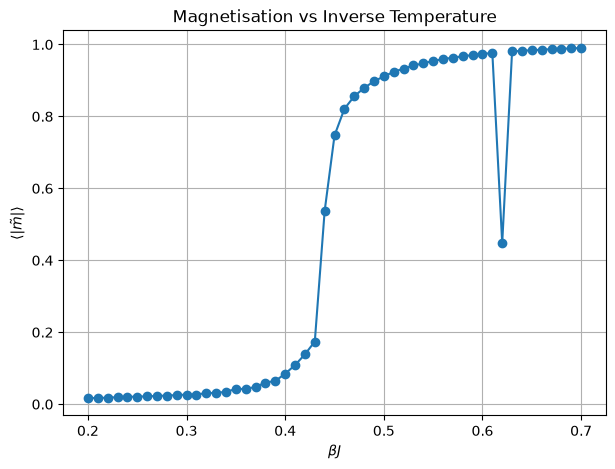

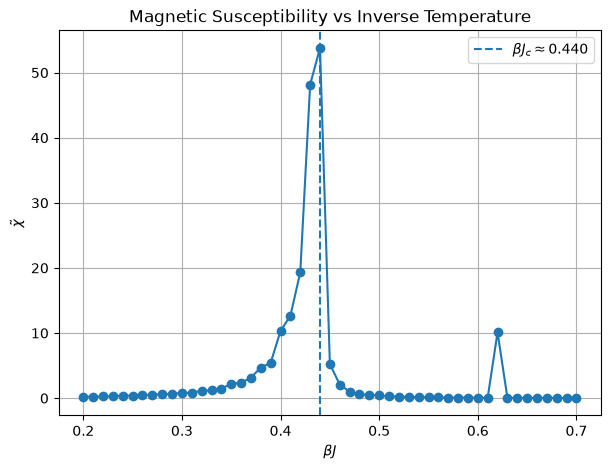

Estimated critical beta J = 0.440


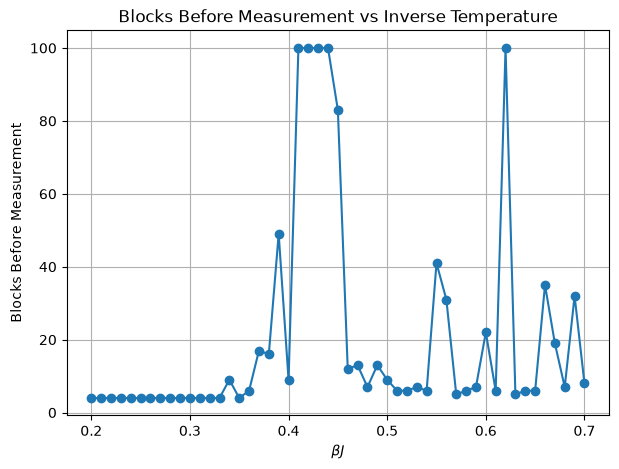

In [ ]:
plot_magnetisations(BJ_values, magnetisations)
plot_susceptibilities(BJ_values, susceptibilities)
plot_equilibration_blocks(BJ_values, equilibration_blocks)

The run shows an anomaly at $BJ=0.62$, where the simulation reached `max_blocks` without satisfying the equilibrium criterion. One possible explanation is that the lattice became trapped in a configuration containing large $+1$ and $-1$ regions, though this cannot be confirmed without inspecting the final lattice.

# 2. Estimating Critical Temperature

For the finite lattice at zero field, susceptibility is calculated using $\langle|\tilde m|\rangle^2$ rather than $\langle\tilde m\rangle^2$. This prevents switches between the equivalent positive- and negative-magnetisation states from being counted as large magnetic fluctuations.

In [ ]:
# parameters
BJ_values = np.arange(0.41, 0.451, 0.002)

num_experiments = 10 # how many runs to average over
burn_in_blocks = 50 # how many burn-in blocks
measurement_blocks = 100 # how many blocks to take measurements over

all_magnetisations = []
all_susceptibilities = []

In [ ]:
# execution

N = L**2
burn_in_steps = burn_in_blocks * num_sweeps_per_block * N
measurement_steps = measurement_blocks * num_sweeps_per_block * N

for experiment in range(num_experiments):
    magnetisations = []
    susceptibilities = []


    for BJ in tqdm(BJ_values, desc=f"Experiment {experiment + 1}/{num_experiments}", leave=True):
        lattice = ut.generate_lattice(L)
        energy = ut.get_energy(lattice, H)

        # burn-in
        lattice, _, energies, _ = ut.metropolis(lattice, burn_in_steps, BJ, H, energy)
        energy = energies[-1]

        # actual measurement
        _, spins, _, _ = ut.metropolis(lattice, measurement_steps, BJ, H, energy)
        m = spins / N
        mean_abs_m = np.mean(np.abs(m))
        chi = BJ * N * (np.mean(m**2) - np.mean(np.abs(m))**2)

        magnetisations.append(mean_abs_m)
        susceptibilities.append(chi)

    all_magnetisations.append(magnetisations)
    all_susceptibilities.append(susceptibilities)
        
mean_magnetisations = np.mean(all_magnetisations, axis=0)
mean_susceptibilities = np.mean(all_susceptibilities, axis=0)

Experiment 1/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 2/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 3/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 4/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 5/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 6/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 7/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 8/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 9/10:   0%|          | 0/21 [00:00<?, ?it/s]

Experiment 10/10:   0%|          | 0/21 [00:00<?, ?it/s]

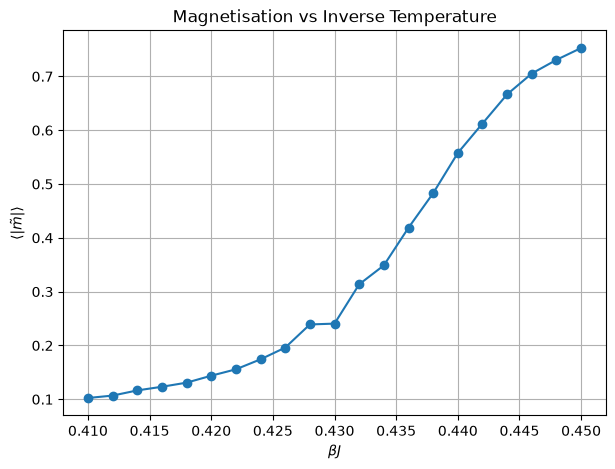

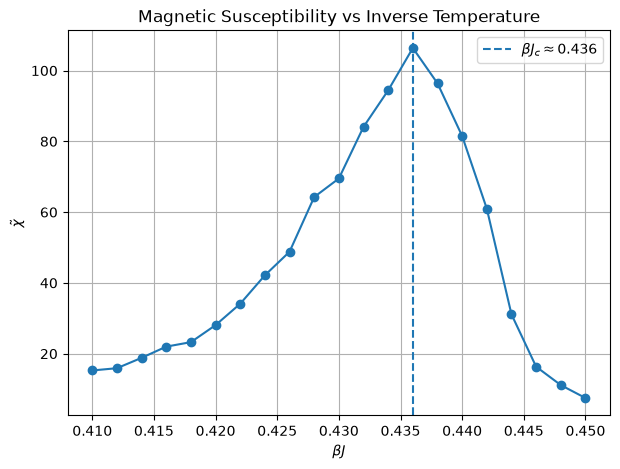

Estimated critical beta J = 0.436


In [104]:
plot_magnetisations(BJ_values, mean_magnetisations)
plot_susceptibilities(BJ_values, mean_susceptibilities)